In [18]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget, RunSelectorUI, scan_runs
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [153]:
pgroup = 'p23106'
#runlist = np.arange(205, 224)
runlist = [76,77]

data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 76


100%|██████████| 67/67 [00:31<00:00,  2.15it/s]


Processing run 77


100%|██████████| 67/67 [00:31<00:00,  2.13it/s]


In [89]:
#plot_merged_data(data, meta, Signal='diode1', Izero='Izero122', TT='126', withTT=True, bins=100, figsize=(10, 3))

In [154]:
ui, out  = Rebin_widget(data=data)
ui

In [155]:
data_plot1 = out["signal1"]
data_plot2 = out["signal2"]

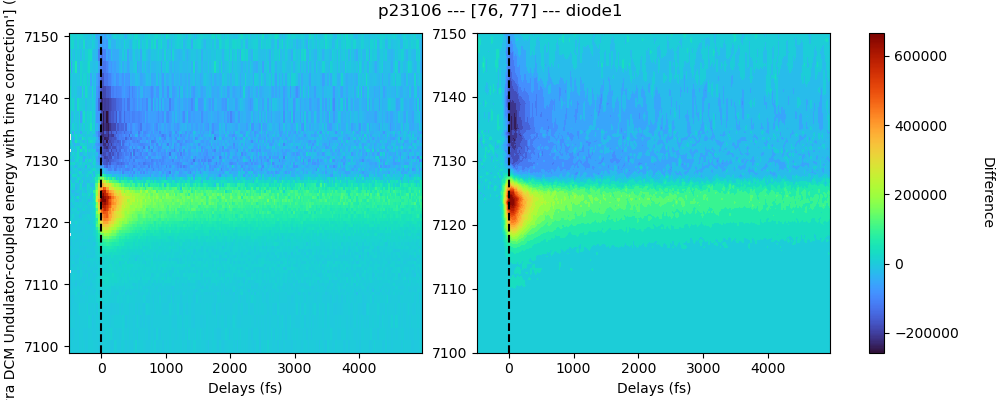

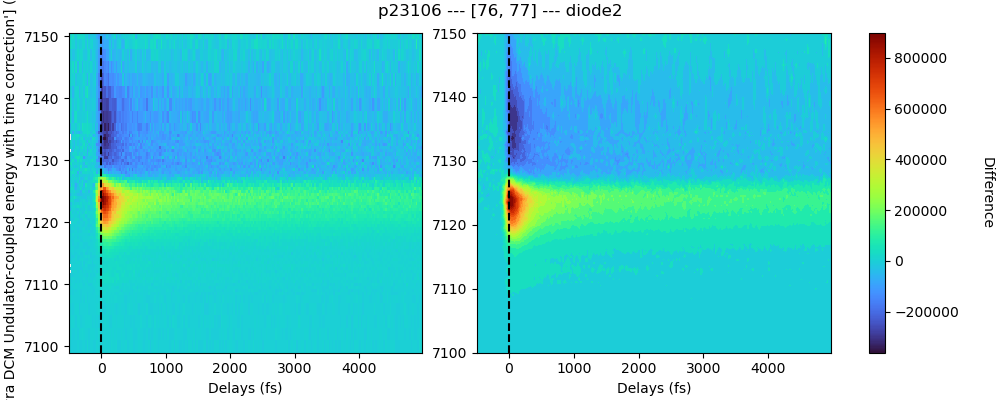

In [156]:
fig, axes = plotter.TwoD_scans(data_plot1, meta) #, vmin=-0.02, vmax=0.02)
fig, axes = plotter.TwoD_scans(data_plot2, meta) #, vmin=0, vmax=20000)

Delay integration range smaller than delay bin


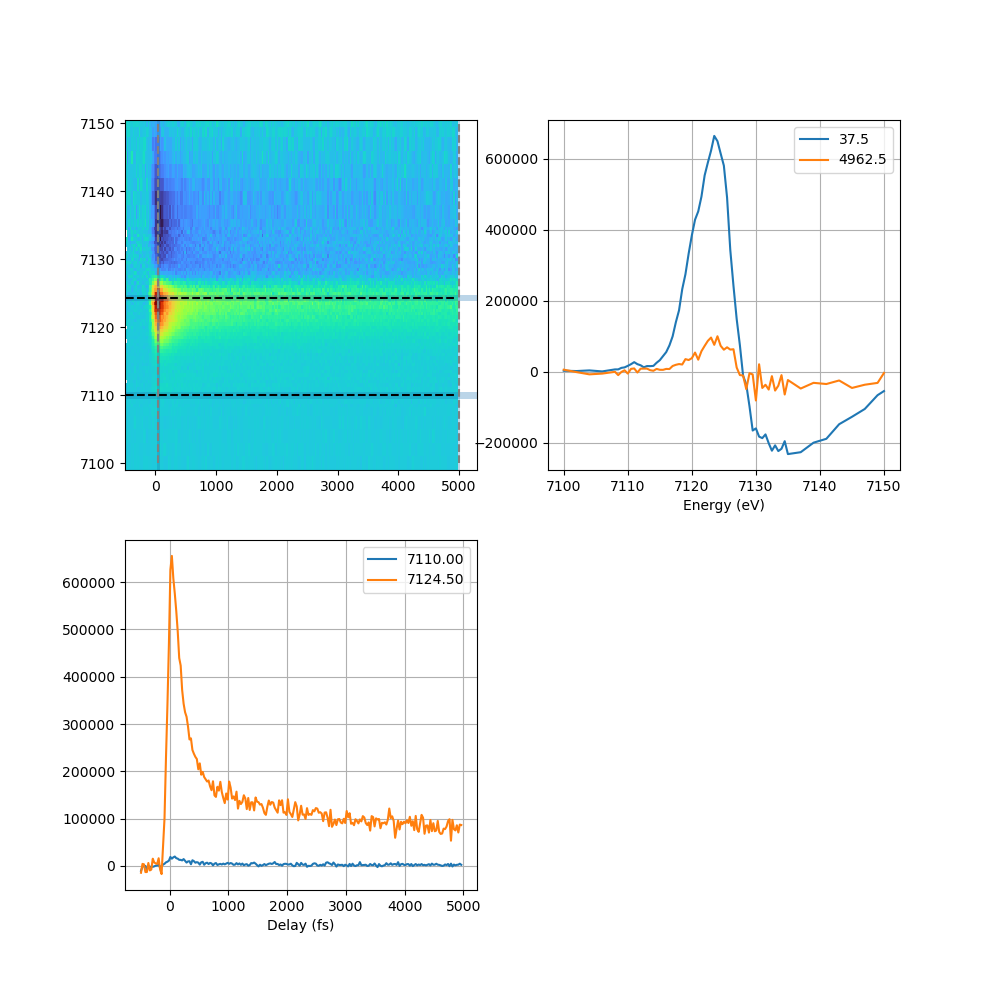

In [159]:
#energylist = [2470.0, 2471.7, 2472.5,  2475.5]
#delayslist = [0, 25, 50, 100, 200, 500, 800]
energylist = [7110, 7124.3]
delayslist = [50,5000]

fig, axes = plotter.TwoD_scans_lineouts(data_plot1, meta, energylist, delayslist, delay_int=45, energy_int = 1, figsize=(10,10))#, vmin=-0.02, vmax=0.02)

In [135]:
SaveDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=None)

Data saved in /sf/alvra/data/p23106/work/Reduced_data/_multiruns/run0064_0065/


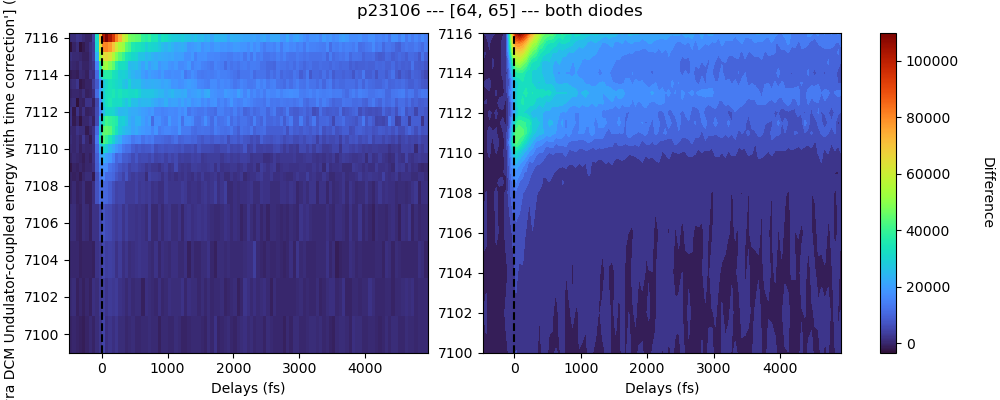

In [136]:
data_plot_both = average_two_diodes(data_plot1, data_plot2)
fig, axes = plotter.TwoD_scans(data_plot_both, meta)

In [100]:
pgroup = 'p23106'
which_plot = 'plot1' #both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
selector = RunSelectorUI(LoadDir)

Loaded __diode1__ from: /sf/alvra/data/p23106/work/Reduced_data/_multiruns/run0024_0048_0049_0054/data.npz


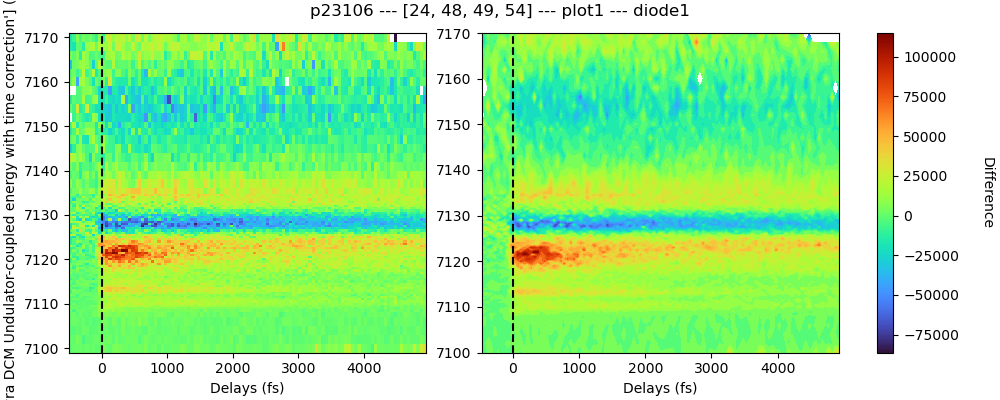

In [109]:
runlist2load = selector.runlist
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
meta.update({'title': '{} --- {} --- {}'.format(pgroup, str(runlist2load[0]), which_plot)})
fig, axes = plotter.TwoD_scans(dataLoaded[0], meta) #, vmin=-0.02, vmax=0.02)

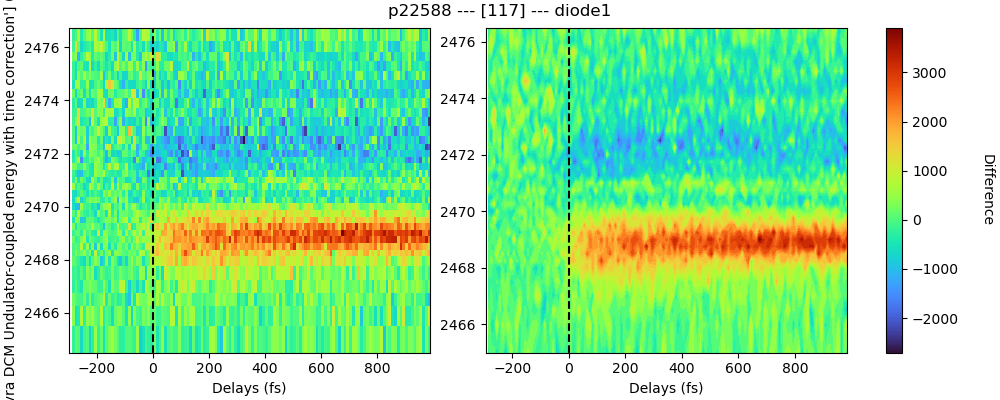

In [29]:
fig, axes = plotter.TwoD_scans(dataLoaded[0], meta) #, vmin=-0.02, vmax=0.02)